<a href="https://colab.research.google.com/github/aditya5203/Artificial-Intelligence-and-Machine-Learning/blob/main/workshop_5_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from PIL import Image
import os

train_dir = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/FruitinAmazon/train"

corrupted = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_dir = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/FruitinAmazon/train"

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [9]:
import tensorflow as tf

train_dir = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/FruitinAmazon/train"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

# ✅ IMPORTANT LINE
class_names = train_ds.class_names

print(class_names)   # check

Found 90 files belonging to 6 classes.
Using 72 files for training.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 741ms/step - accuracy: 0.1528 - loss: 608.6838 - val_accuracy: 0.1111 - val_loss: 3.1277
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 556ms/step - accuracy: 0.1250 - loss: 473.5091 - val_accuracy: 0.1667 - val_loss: 1.9150
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 564ms/step - accuracy: 0.2361 - loss: 122.1965 - val_accuracy: 0.1667 - val_loss: 1.7606
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 845ms/step - accuracy: 0.3333 - loss: 12.0301 - val_accuracy: 0.2222 - val_loss: 1.7740
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 753ms/step - accuracy: 0.4306 - loss: 2.6497 - val_accuracy: 0.2222 - val_loss: 1.7864
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 455ms/step - accuracy: 0.6250 - loss: 1.0853 - val_accuracy: 0.2778 - val_loss: 1.7920
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 484ms/step - accuracy: 0.7083 - loss: 0.9218 - val_accuracy: 0.2222 - val_loss: 1.7918
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 0.7917 - loss: 0.7527 - val_accuracy: 0.2222 - va

In [12]:
# Save
model.save("cnn_fruit_model.keras")

# Load
loaded_model = tf.keras.models.load_model("cnn_fruit_model.keras")

# Compile again
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Re-evaluate
loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step - accuracy: 0.1667 - loss: 1.7606


[1.7605904340744019, 0.1666666716337204]

In [13]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = loaded_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
              precision    recall  f1-score   support

        acai       0.25      1.00      0.40         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.00      0.00      0.00         3
     guarana       0.20      0.40      0.27         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.17        18
   macro avg       0.07      0.23      0.11        18
weighted avg       0.07      0.17      0.10        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


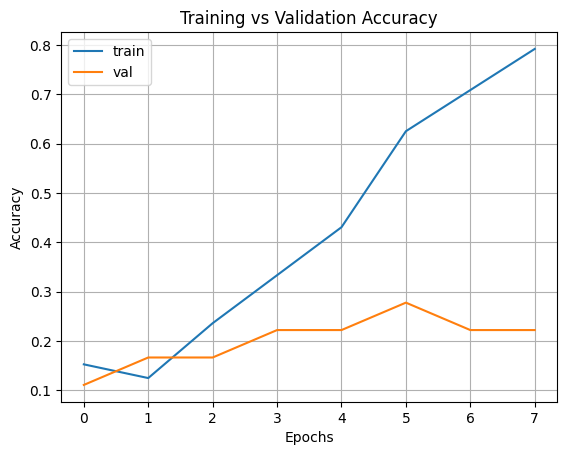

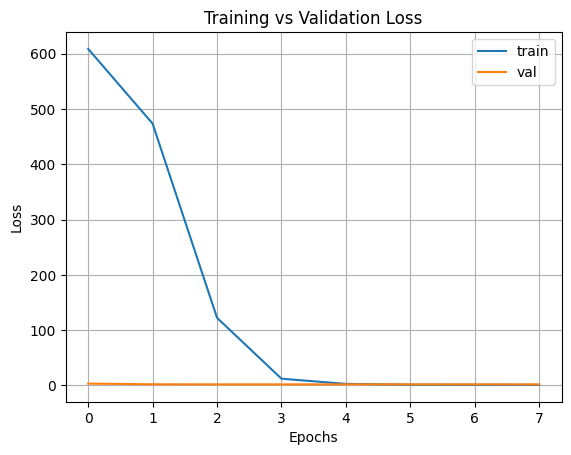

In [14]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train','val'])
plt.grid()
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train','val'])
plt.grid()
plt.show()